# fatma salah mahdy

In [ ]:
import numpy as np

#for data processing
import pandas as pd

#for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('Hotel Reservations.csv')

In [ ]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [ ]:
del df['Booking_ID']

In [ ]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [ ]:
df[:2].iloc[:, :-1].values


array([[2, 0, 1, 2, 'Meal Plan 1', 0, 'Room_Type 1', 224, 2017, 10, 2,
        'Offline', 0, 0, 0, 65.0, 0],
       [2, 0, 2, 3, 'Not Selected', 0, 'Room_Type 1', 5, 2018, 11, 6,
        'Online', 0, 0, 0, 106.68, 1]], dtype=object)

In [ ]:
df[:2].iloc[:, -1:].values

array([['Not_Canceled'],
       ['Not_Canceled']], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
df['type_of_meal_plan']=label_encoder.fit_transform(df['type_of_meal_plan'])
df['room_type_reserved']=label_encoder.fit_transform(df['room_type_reserved'])
df['market_segment_type']=label_encoder.fit_transform(df['market_segment_type'])
df['booking_status']=label_encoder.fit_transform(df['booking_status'])

In [ ]:
df[:5]

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,0,0,0,224,2017,10,2,3,0,0,0,65.00,0,1
1,2,0,2,3,3,0,0,5,2018,11,6,4,0,0,0,106.68,1,1
2,1,0,2,1,0,0,0,1,2018,2,28,4,0,0,0,60.00,0,0
3,2,0,0,2,0,0,0,211,2018,5,20,4,0,0,0,100.00,0,0
4,2,0,1,1,3,0,0,48,2018,4,11,4,0,0,0,94.50,0,0


In [ ]:
X=df.iloc[:, :-1].values
y=df.iloc[:, -1:].values
# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

#Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
import keras

In [ ]:

from keras.models import Sequential
from keras.layers import Dense,Dropout

In [ ]:
# prompt: need Dense layers for this task of breast cancer
classifier = Sequential()

# Adding the input layer and the first hidden layer
classifier.add(Dense(units = 50, kernel_initializer = 'uniform', activation = 'relu', input_dim = 17))
# Adding dropout to prevent overfitting
classifier.add(Dropout(rate = 0.1))

# Adding the second hidden layer
classifier.add(Dense(units = 30, kernel_initializer = 'uniform', activation = 'relu'))
# Adding dropout to prevent overfitting
classifier.add(Dropout(rate = 0.1))

# Adding the second hidden layer
classifier.add(Dense(units = 15, kernel_initializer = 'uniform', activation = 'relu'))
# Adding dropout to prevent overfitting
classifier.add(Dropout(rate = 0.1))

# Adding the output layer
classifier.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))  # 0 - 1   >=0.5 ? 1 , 0


In [ ]:
classifier.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                     │ (None, 50)                  │             900 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_29 (Dropout)                 │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_40 (Dense)                     │ (None, 30)                  │           1,530 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_30 (Dropout)                 │ (None, 30)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ (None, 15)                  │             465 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_31 (Dropout)                 │ (None, 15)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ (None, 1)                   │              16 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,911 (11.37 KB)

 Trainable params: 2,911 (11.37 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
# Fitting the ANN to the Training set

# Train the model

history = classifier.fit(X_train, y_train, validation_split=0.2, batch_size=65, epochs=100,)
# Long scroll ahead but worth
# The batch size and number of epochs have been set using trial and error. Still looking for more efficient ways. Open to suggestions.

Epoch 1/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7078 - loss: 0.5667 - val_accuracy: 0.8125 - val_loss: 0.4271
Epoch 2/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8139 - loss: 0.4215 - val_accuracy: 0.8206 - val_loss: 0.4097
Epoch 3/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8122 - loss: 0.4126 - val_accuracy: 0.8260 - val_loss: 0.4045
Epoch 4/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8186 - loss: 0.4095 - val_accuracy: 0.8196 - val_loss: 0.3997
Epoch 5/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8219 - loss: 0.3963 - val_accuracy: 0.8260 - val_loss: 0.3960
Epoch 6/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8228 - loss: 0.3974 - val_accuracy: 0.8246 - val_loss: 0.3937
Epoch 7/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8228 - loss: 0.3970 - val_accuracy: 0.8293 - val_loss: 0.3878
Epoch 8/100
358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8294 - loss: 0.3885 - val_accu

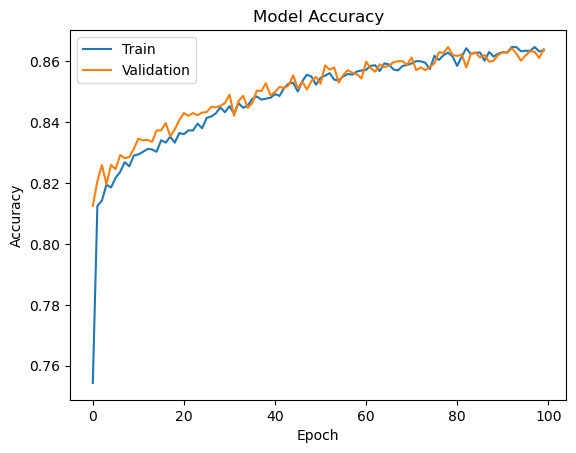

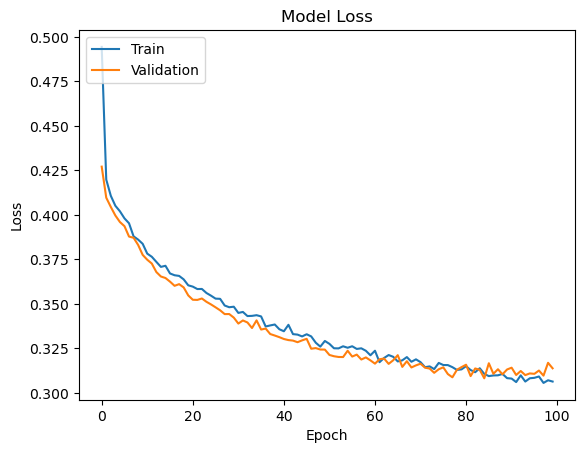

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy']) # Access history from the 'history' object
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss']) # Access history from the 'history' object
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
y_pred = classifier.predict(X_test)
y_pred = (y_pred>=.5)

227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step


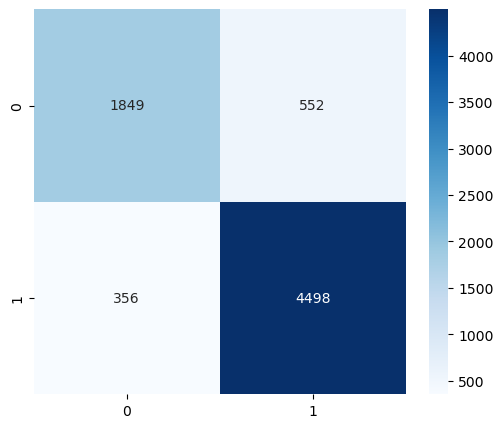

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, cmap="Blues", annot=True, fmt='g')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred,digits=4))

              precision    recall  f1-score   support

           0     0.8385    0.7701    0.8029      2401
           1     0.8907    0.9267    0.9083      4854

    accuracy                         0.8748      7255
   macro avg     0.8646    0.8484    0.8556      7255
weighted avg     0.8734    0.8748    0.8734      7255

